# Hackett 2020 vs Kemmeren Correlation Analysis Tutorial

This tutorial demonstrates how to conduct comprehensive correlation analysis between Hackett 2020 (mcisaac) and Kemmeren datasets using tfbpapi, focusing on regulator-target relationships and temporal dynamics.

## Overview

Correlation analysis evalute how well the effects of the same regulators correlate between these two experimental approaches, and whether timing affects the correlation strength.

### Datasets Used
- **Perturbation data**: McIsaac (ZEV system), Kemmeren (overexpression)

### Analysis Strategy
1. Load and filter Hackett 2020 data (time=15, mechanism="zev", restriction="p") and Kemmeren 2014 data
2. Identify shared regulators between Hackett and Kemmeren
3. For each shared regulator, calculate Spearman correlations:
   - Hackett effect vs Kemmeren effect
   - Hackett effect vs Kemmeren p-value
4. Generate scatter plots for specific individual regulator
5. Create distribution plots (boxplots) across all shared regulators
6. Analyze temporal dynamics by comparing different timepoints in Hackett data

In [1]:
import pandas as pd
import numpy as np
from tfbpapi.HfQueryAPI import HfQueryAPI
from tfbpapi.datainfo.datacard import DataCard
from tfbpapi.errors import DataCardError, HfDataFetchError
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
import seaborn as sns

# Configure plotting
plt.style.use('default')
sns.set_palette("husl")

/home/chase/code/tfbp/tfbpapi/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Dataset Exploration with DataCard

Before loading data, let's explore dataset structure and metadata using the DataCard interface.

In [2]:
# Explore dataset structure using DataCard
print("Exploring dataset structures...")

datasets_to_explore = [
    "BrentLab/hackett_2020",
    "BrentLab/kemmeren_2014"
]

dataset_info = {}

for repo_id in datasets_to_explore:
    try:
        print(f"\n{'='*50}")
        print(f"Exploring {repo_id}")

        # Create DataCard instance
        datacard = DataCard(repo_id)
        card = datacard.dataset_card

        # DatasetCard doesn't have dataset_type directly - it's on individual configs
        dataset_types = [config.dataset_type.value for config in card.configs]
        print(f"Dataset types in configs: {set(dataset_types)}")
        print(f"Configurations: {len(card.configs)}")

        # Store dataset info for later use
        dataset_info[repo_id] = {
            'datacard': datacard,
            'card': card,
            'configs': {config.config_name: config for config in card.configs}
        }

        # Display configuration details
        for config in card.configs:
            print(f"\nConfig: {config.config_name}")
            print(f"  Type: {config.dataset_type.value}")
            print(f"  Features: {len(config.dataset_info.features) if config.dataset_info.features else 0}")

            if config.dataset_info.features:
                # Show regulator and target fields if available
                feature_names = [f.name for f in config.dataset_info.features]
                regulator_fields = [f for f in feature_names if 'regulator' in f.lower()]
                target_fields = [f for f in feature_names if 'target' in f.lower()]

                if regulator_fields:
                    print(f"  Regulator fields: {regulator_fields}")
                if target_fields:
                    print(f"  Target fields: {target_fields}")

            if config.metadata_fields:
                print(f"  Metadata fields: {config.metadata_fields}")

    except (DataCardError, HfDataFetchError) as e:
        print(f"Error exploring {repo_id}: {e}")
        continue
    except Exception as e:
        print(f"Unexpected error exploring {repo_id}: {e}")
        continue

print(f"\n{'='*50}")
print(f"Successfully explored {len(dataset_info)} datasets")

Exploring dataset structures...

Exploring BrentLab/hackett_2020
Dataset types in configs: {'annotated_features'}
Configurations: 1

Config: hackett_2020
  Type: annotated_features
  Features: 17
  Regulator fields: ['regulator_locus_tag', 'regulator_symbol']
  Target fields: ['target_locus_tag', 'target_symbol']
  Metadata fields: ['regulator_locus_tag', 'regulator_symbol', 'time', 'mechanism', 'restriction', 'date', 'strain']

Exploring BrentLab/kemmeren_2014
Dataset types in configs: {'annotated_features'}
Configurations: 1

Config: kemmeren_2014
  Type: annotated_features
  Features: 11
  Regulator fields: ['regulator_locus_tag', 'regulator_symbol']
  Target fields: ['target_locus_tag', 'target_symbol']
  Metadata fields: ['regulator_locus_tag', 'regulator_symbol']

Successfully explored 2 datasets


## Initialize dataset connections and load data

In [3]:
# Initialize dataset connections and load data
print("Initializing HfQueryAPI connections...")

hackett_2020 = HfQueryAPI(repo_id="BrentLab/hackett_2020")
kemmeren_2014 = HfQueryAPI(repo_id="BrentLab/kemmeren_2014")

print("All API connections initialized")

Initializing HfQueryAPI connections...
All API connections initialized


## Get metadata from each dataset to find common regulators

In [4]:
# Get metadata from each dataset to find common regulators
print("Getting metadata from datasets...")

kemmeren_meta = kemmeren_2014.get_metadata("kemmeren_2014") 
hackett_2020_meta = hackett_2020.get_metadata("hackett_2020")

print("All metadata loaded")

# Get the intersection of common regulators
common_regulators = (set(hackett_2020_meta.regulator_symbol.unique())
                    & set(kemmeren_meta.regulator_symbol.unique()))

print(f"Found {len(common_regulators)} common regulators across all datasets")

# Create proper SQL IN clause
if common_regulators:
    regulator_clause = "(" + ", ".join(f"'{reg}'" for reg in common_regulators) + ")"

Getting metadata from datasets...
All metadata loaded
Found 185 common regulators across all datasets


## Filter the data

In [5]:
# Apply dataset-specific filters
print("Applying dataset-specific filters...")

hackett_2020.set_sql_filter(
    "hackett_2020",
    f"""
        time = 15 
        AND mechanism = 'ZEV' 
        AND restriction = 'P' 
        AND regulator_symbol IN {regulator_clause}
    """)

print("All filters applied")

Applying dataset-specific filters...
All filters applied


In [6]:
# Load both perturbation datasets to find common regulators
print("Loading both perturbation datasets...")

# Load both datasets
hackett_data = hackett_2020.query("SELECT * FROM hackett_2020", "hackett_2020")
kemmeren_data = kemmeren_2014.query("SELECT * FROM kemmeren_2014", "kemmeren_2014")

print("Both datasets loaded")

# Check what regulators we actually got from each dataset
actual_regulators = {
    'hackett': set(hackett_data.regulator_symbol.unique()),
    'kemmeren': set(kemmeren_data.regulator_symbol.unique()),
}

for name, regulators in actual_regulators.items():
    print(f"{name}: {len(regulators)} regulators")

# Find the intersection - regulators present in BOTH datasets
final_common = set.intersection(*actual_regulators.values())
print(f"Final intersection: {len(final_common)} regulators")

if final_common:
    final_common_clause = "(" + ", ".join(f"'{reg}'" for reg in final_common) + ")"
    print(f"Common regulators: {sorted(list(final_common))[:10]}...")  # Show first 10
else:
    print("WARNING: No common regulators found!")
    final_common_clause = "()"


Loading both perturbation datasets...
Both datasets loaded
hackett: 145 regulators
kemmeren: 1487 regulators
Final intersection: 145 regulators
Common regulators: ['ACA1', 'ADA2', 'AFT2', 'ARO80', 'ARR1', 'ASH1', 'AZF1', 'BDF2', 'BMH1', 'CAD1']...


In [7]:
# Find common targets across all datasets
print("Finding common targets...")

common_targets = (set(hackett_data.target_symbol.unique())
                & set(kemmeren_data.target_symbol.unique()))

print(f"Found {len(common_targets)} common targets")

if common_targets:
    target_clause = "(" + ", ".join(f"'{tgt}'" for tgt in common_targets) + ")"

# Load final datasets with both regulator and target filtering  
print("Loading final datasets with complete filtering...")


# Load final datasets with both regulator and target filtering  
hackett_final = hackett_2020.query(f"""
    SELECT * FROM hackett_2020
    WHERE regulator_symbol IN {final_common_clause} 
    AND target_symbol IN {target_clause}
""", "hackett_2020")

kemmeren_final = kemmeren_2014.query(f"""
    SELECT * FROM kemmeren_2014
    WHERE regulator_symbol IN {final_common_clause} 
    AND target_symbol IN {target_clause}
""", "kemmeren_2014")

print("Final datasets loaded with complete filtering")

# Print final dataset sizes
datasets_info = [
    ('McIsaac', hackett_final), ('Kemmeren', kemmeren_final)
]

for name, data in datasets_info:
    if len(data) > 0:
        regulators = data['regulator_symbol'].nunique() if 'regulator_symbol' in data.columns else 0
        print(f"{name}: {len(data):,} rows, {regulators} regulators")
    else:
        print(f"{name}: No data loaded")

Finding common targets...
Found 6063 common targets
Loading final datasets with complete filtering...
Final datasets loaded with complete filtering
McIsaac: 891,408 rows, 145 regulators
Kemmeren: 880,730 rows, 145 regulators


In [8]:
kemmeren_final

,regulator_locus_tag,regulator_symbol,reporterId,target_locus_tag,target_symbol,M,Madj,A,pval,variable_in_wt,multiple_probes
0,YBL008W,HIR1,SCAB000002,Q0017,Q0017,-0.039026,-0.039721,5.666642,0.591335,False,False
1,YBL008W,HIR1,SCAB000004,Q0045,COX1,-0.102708,-0.104404,7.187218,0.278744,False,False
2,YBL008W,HIR1,SCAB000005,Q0050,AI1,-0.092154,-0.101312,7.981813,0.789989,True,False
3,YBL008W,HIR1,SCAB000006,Q0055,AI2,-0.113634,-0.123208,9.302573,0.695235,True,False
4,YBL008W,HIR1,SCAB000007,Q0060,AI3,-0.009983,-0.018676,8.315141,0.975177,False,False
...,...,...,...,...,...,...,...,...,...,...,...
880725,YPL202C,AFT2,SCAB007301,YML099W-A,YML099W-A,-0.141110,-0.116465,8.092513,0.432310,False,False
880726,YPL202C,AFT2,SCAB007304,YNL067W-A,YNL067W-A,0.015283,-0.000849,6.472535,0.969828,False,False
880727,YPL202C,AFT2,SCAB007305,YNL162W-A,YNL162W-A,0.118187,0.061836,9.364032,0.696226,False,False
880728,YPL202C,AFT2,SCAB007306,YNR001W-A,YNR001W-A,0.027918,0.020460,6.351764,0.944834,False,False


In [9]:
hackett_final

,regulator_locus_tag,regulator_symbol,target_locus_tag,target_symbol,time,mechanism,restriction,date,strain,green_median,red_median,log2_ratio,log2_cleaned_ratio,log2_noise_model,log2_cleaned_ratio_zth2d,log2_selected_timecourses,log2_shrunken_timecourses
0,YER045C,ACA1,YNL055C,POR1,15.0,ZEV,P,20160229,SMY2049,91090.29500,124164.750000,0.406527,0.043278,0.167308,0.000000,0.000000,0.00000
1,YER045C,ACA1,YIL114C,POR2,15.0,ZEV,P,20160229,SMY2049,929.49180,662.373950,-0.084262,-0.097770,0.129415,-0.000000,0.000000,0.00000
2,YER045C,ACA1,YPL188W,POS5,15.0,ZEV,P,20160229,SMY2049,591.31345,734.788500,-0.075808,-0.050857,0.107884,-0.000000,0.000000,0.00000
3,YER045C,ACA1,YIL160C,POT1,15.0,ZEV,P,20160229,SMY2049,205.71685,121.719000,0.584763,0.170594,0.215646,0.170594,0.170594,0.00463
4,YER045C,ACA1,YGL205W,POX1,15.0,ZEV,P,20160229,SMY2049,119.50650,87.946405,0.179057,0.020029,0.198205,0.000000,0.000000,0.00000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
891403,YFL052W,ZNF1,YGL087C,MMS2,15.0,ZEV,P,20161117,SMY2245,923.69900,662.456500,0.028204,-0.004566,0.117553,-0.000000,0.000000,0.00000
891404,YFL052W,ZNF1,YKL175W,ZRT3,15.0,ZEV,P,20161117,SMY2245,5181.16750,3997.746500,-0.136347,-0.054108,0.096181,-0.000000,0.000000,0.00000
891405,YFL052W,ZNF1,YBR046C,ZTA1,15.0,ZEV,P,20161117,SMY2245,466.54105,581.044100,0.342384,0.014190,0.139531,0.000000,0.000000,0.00000
891406,YFL052W,ZNF1,YGR285C,ZUO1,15.0,ZEV,P,20161117,SMY2245,16498.73500,17306.235000,-0.143440,-0.057246,0.090285,-0.000000,0.000000,0.00000


## Individual regulator correlation analysis and scatter plots

Now we'll analyze correlations for each regulator individually, focusing on the relationship between Hackett effects and Kemmeren effects/p-values.


In [10]:
import numpy as np
from scipy.stats import spearmanr

# Set up plotting parameters
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 10

# Example regulator symbol
chosen_regulator_symbol = 'ACA1'
    
# Filter data for the specific regulator
hackett_reg = hackett_final[hackett_final['regulator_symbol'] == chosen_regulator_symbol].copy()
kemmeren_reg = kemmeren_final[kemmeren_final['regulator_symbol'] == chosen_regulator_symbol].copy()
    
# Check if data was found
if len(hackett_reg) == 0 or len(kemmeren_reg) == 0:
    print(f"No data found for regulator {chosen_regulator_symbol}")
    
# Merge datasets on target_symbol
merged = pd.merge(
    hackett_reg[['target_symbol', 'log2_shrunken_timecourses']].rename(columns={'log2_shrunken_timecourses': 'effect_hackett'}),
    kemmeren_reg[['target_symbol', 'Madj', 'pval']].rename(columns={'Madj': 'effect_kemmeren', 'pval': 'pvalue_kemmeren'}),
    on='target_symbol',
    how='inner'
)
    
if len(merged) < 3:  # Need at least 3 points for correlation
    print(f"Insufficient data points ({len(merged)}) for regulator {chosen_regulator_symbol}")

    
# Calculate correlations
# Remove any NaN values
clean_data = merged.dropna(subset=['effect_hackett', 'effect_kemmeren', 'pvalue_kemmeren'])
    
if len(clean_data) < 3:
    print(f"Insufficient clean data points ({len(clean_data)}) for regulator {chosen_regulator_symbol}")
    
# Spearman correlations
eff_eff_corr, eff_eff_pval = spearmanr(clean_data['effect_hackett'], clean_data['effect_kemmeren'])
eff_pval_corr, eff_pval_pval = spearmanr(clean_data['effect_hackett'], clean_data['pvalue_kemmeren'])
    
correlation_results = {
    'regulator_symbol': chosen_regulator_symbol,
    'n_targets': len(clean_data),
    'eff_eff_corr': eff_eff_corr,
    'eff_eff_pval': eff_eff_pval,
    'eff_pval_corr': eff_pval_corr,
    'eff_pval_pval': eff_pval_pval
}
    
print(correlation_results)
print("Correlation analysis function finished!")


{'regulator_symbol': 'ACA1', 'n_targets': 6075, 'eff_eff_corr': np.float64(0.01608402414610723), 'eff_eff_pval': np.float64(0.21004245167836072), 'eff_pval_corr': np.float64(-0.017860635301765383), 'eff_pval_pval': np.float64(0.1639456246498038)}
Correlation analysis function finished!


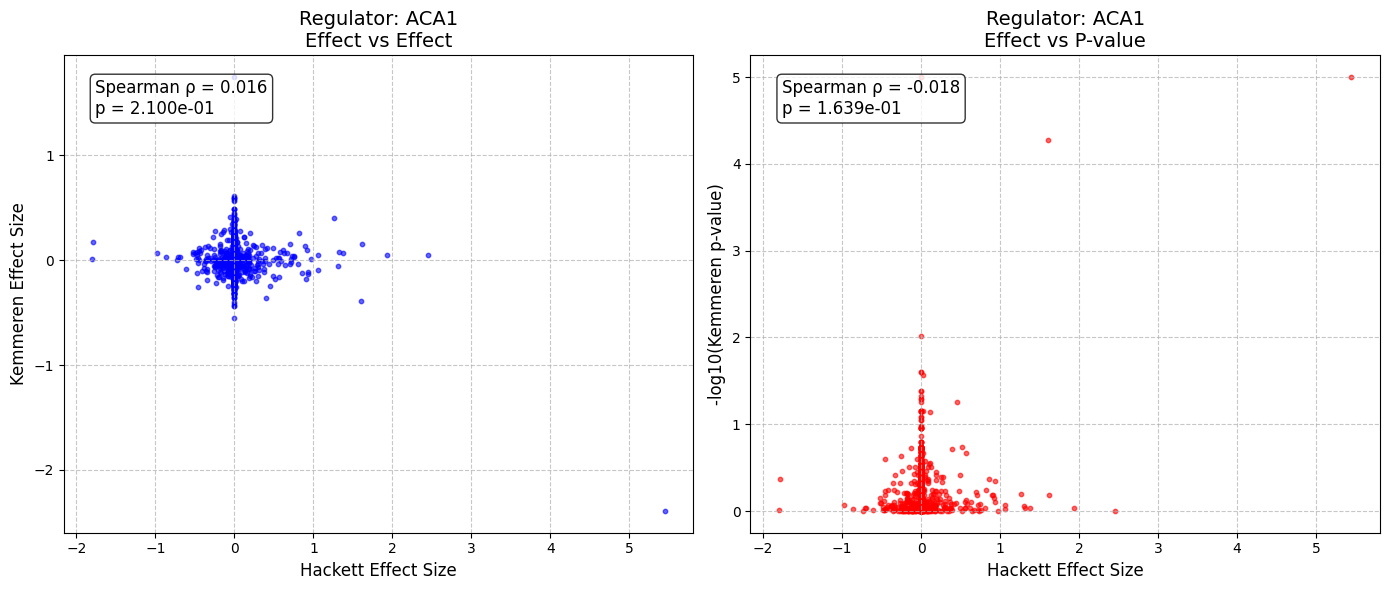

In [11]:
# create scatter plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# scatter plot1: Hackett effect vs Kemmeren effect
scatter1 = ax1.scatter(clean_data['effect_hackett'], clean_data['effect_kemmeren'], 
                       alpha=0.6, s=10, c='blue')
ax1.set_xlabel('Hackett Effect Size', fontsize=12)
ax1.set_ylabel('Kemmeren Effect Size', fontsize=12)
ax1.set_title(f'Regulator: {chosen_regulator_symbol}\nEffect vs Effect', fontsize=14)
# Add correlation coefficient text
ax1.text(0.05, 0.95, f'Spearman ρ = {eff_eff_corr:.3f}\np = {eff_eff_pval:.3e}', 
         transform=ax1.transAxes, fontsize=12, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
ax1.grid(True, linestyle='--', alpha=0.7)

# scatter plot2: Hackett effect vs Kemmeren pvalue
# Set a minimum p-value to ensure that -log10(p) does not exceed the range of the plot
min_pvalue = 10**(-5)  

# copy pvalue column and replace 0 values
pvalue_for_plot = clean_data['pvalue_kemmeren'].copy()
pvalue_for_plot[pvalue_for_plot == 0] = min_pvalue

# calculate log_pvalue
log_pvalue = -np.log10(pvalue_for_plot)

scatter2 = ax2.scatter(clean_data['effect_hackett'], log_pvalue, 
                       alpha=0.6, s=10, c='red')
ax2.set_xlabel('Hackett Effect Size', fontsize=12)
ax2.set_ylabel('-log10(Kemmeren p-value)', fontsize=12)
ax2.set_title(f'Regulator: {chosen_regulator_symbol}\nEffect vs P-value', fontsize=14)
# Add correlation coefficient text
ax2.text(0.05, 0.95, f'Spearman ρ = {eff_pval_corr:.3f}\np = {eff_pval_pval:.3e}', 
         transform=ax2.transAxes, fontsize=12, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

## Make distributions over the shared regulators

In [12]:
from typing import Dict, Any, Optional

# Functional encapsulation
# Calculate the correlation between the two datasets for a given regulator
def calculate_regulator_correlation(
    chosen_regulator_symbol: str, 
    hackett_final: pd.DataFrame, 
    kemmeren_final: pd.DataFrame
) -> Optional[Dict[str, Any]]:
    """
    Parameters:
    chosen_regulator_symbol (str): The regulator symbol to be analyzed
    hackett_final (DataFrame): Filtered Hackett dataset
    kemmeren_final (DataFrame): Kemmeren dataset

    Returns:
    dict: Dictionary containing correlation coefficients and other 
    statistical information, returns None if insufficient data
    """
    # Filter data for the specific regulator
    hackett_reg = hackett_final[hackett_final['regulator_symbol'] == chosen_regulator_symbol].copy()
    kemmeren_reg = kemmeren_final[kemmeren_final['regulator_symbol'] == chosen_regulator_symbol].copy()
    
    # Check if data was found
    if len(hackett_reg) == 0 or len(kemmeren_reg) == 0:
        print(f"No data found for regulator {chosen_regulator_symbol}")
        return None
    
    # Merge datasets on target_symbol
    merged = pd.merge(
        hackett_reg[['target_symbol', 'log2_shrunken_timecourses']].rename(
            columns={'log2_shrunken_timecourses': 'effect_hackett'}),
        kemmeren_reg[['target_symbol', 'Madj', 'pval']].rename(
            columns={'Madj': 'effect_kemmeren', 'pval': 'pvalue_kemmeren'}),
        on='target_symbol',
        how='inner'
    )
    
    if len(merged) < 3:  # Need at least 3 points for correlation
        print(f"Insufficient data points ({len(merged)}) for regulator {chosen_regulator_symbol}")
        return None
    
    # Calculate correlations
    # Remove any NaN values
    clean_data = merged.dropna(subset=['effect_hackett', 'effect_kemmeren', 'pvalue_kemmeren'])
    
    if len(clean_data) < 3:
        print(f"Insufficient clean data points ({len(clean_data)}) for regulator {chosen_regulator_symbol}")
        return None
    
    # Spearman correlations
    eff_eff_corr, eff_eff_pval = spearmanr(clean_data['effect_hackett'], clean_data['effect_kemmeren'])
    eff_pval_corr, eff_pval_pval = spearmanr(clean_data['effect_hackett'], clean_data['pvalue_kemmeren'])
    
    correlation_results = {
        'regulator_symbol': chosen_regulator_symbol,
        'n_targets': len(clean_data),
        'eff_eff_corr': eff_eff_corr,
        'eff_eff_pval': eff_eff_pval,
        'eff_pval_corr': eff_pval_corr,
        'eff_pval_pval': eff_pval_pval
    }
    
    return correlation_results

In [13]:
# test the function
calculate_regulator_correlation('ACA1', hackett_final, kemmeren_final)


{'regulator_symbol': 'ACA1',
 'n_targets': 6075,
 'eff_eff_corr': np.float64(0.01608402414610723),
 'eff_eff_pval': np.float64(0.21004245167836072),
 'eff_pval_corr': np.float64(-0.017860635301765383),
 'eff_pval_pval': np.float64(0.1639456246498038)}

In [14]:

# Extract unique regulator symbols from the filtered Hackett dataset
regulator_symbols = hackett_final['regulator_symbol'].unique().tolist()

# Initialize an empty list to store all correlation results
all_correlation_results = []

# Loop through each regulator symbol and calculate correlations
for regulator_symbol in regulator_symbols:
    # Calculate correlations for this regulator
    correlation_result = calculate_regulator_correlation(
        regulator_symbol, 
        hackett_final, 
        kemmeren_final
    )
    
    # Only add to results if we got a valid result (not None)
    if correlation_result is not None:
        all_correlation_results.append(correlation_result)

# Convert the list of dictionaries to a DataFrame for easier analysis
results_df = pd.DataFrame(all_correlation_results)

print(f"Successfully calculated correlations for {len(results_df)} regulators")
print(results_df.head())  # Display first few rows

Successfully calculated correlations for 145 regulators
  regulator_symbol  n_targets  eff_eff_corr  eff_eff_pval  eff_pval_corr  \
0             ACA1       6075      0.016084  2.100425e-01      -0.017861   
1             ADA2       6075     -0.100878  3.243911e-15      -0.031116   
2            ARO80       6075     -0.037804  3.209219e-03      -0.027915   
3             AFT2       6075     -0.004887  7.033263e-01       0.034297   
4             ARR1       6075     -0.010794  4.002741e-01      -0.002523   

   eff_pval_pval  
0       0.163946  
1       0.015293  
2       0.029576  
3       0.007507  
4       0.844150  


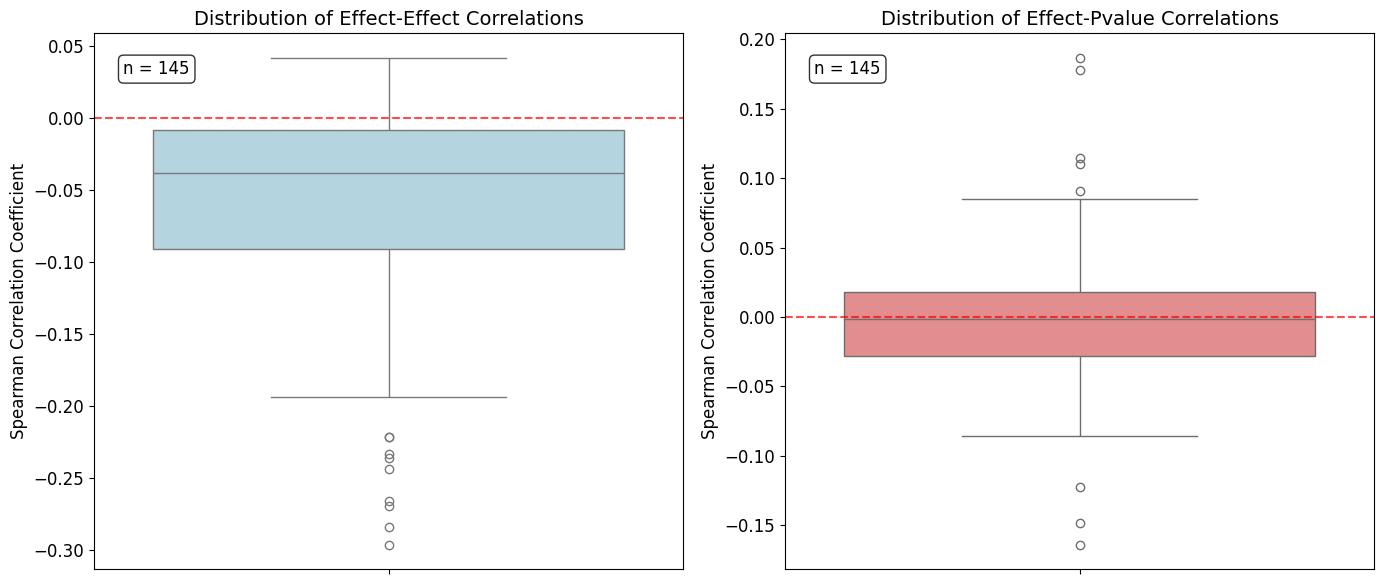

Effect-Effect Correlation Summary:
count    145.000000
mean      -0.058967
std        0.072261
min       -0.296206
25%       -0.091059
50%       -0.037956
75%       -0.008329
max        0.042079
Name: eff_eff_corr, dtype: float64

Effect-Pvalue Correlation Summary:
count    145.000000
mean      -0.002324
std        0.047957
min       -0.164093
25%       -0.028492
50%       -0.001771
75%        0.017656
max        0.186708
Name: eff_pval_corr, dtype: float64


In [15]:
# Set up the plotting style and parameters
plt.style.use('default')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

# Create a figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2)

# First boxplot: Effect-Effect Correlation Distribution
sns.boxplot(data=results_df, y='eff_eff_corr', ax=ax1, color='lightblue')
ax1.set_title('Distribution of Effect-Effect Correlations', fontsize=14)
ax1.set_ylabel('Spearman Correlation Coefficient', fontsize=12)
# Add a horizontal line at y=0 for reference
ax1.axhline(y=0, color='r', linestyle='--', alpha=0.7)
# Add text showing the number of regulators
ax1.text(0.05, 0.95, f'n = {len(results_df)}', transform=ax1.transAxes, 
         fontsize=12, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Second boxplot: Effect-Pvalue Correlation Distribution
sns.boxplot(data=results_df, y='eff_pval_corr', ax=ax2, color='lightcoral')
ax2.set_title('Distribution of Effect-Pvalue Correlations', fontsize=14)
ax2.set_ylabel('Spearman Correlation Coefficient', fontsize=12)
# Add a horizontal line at y=0 for reference
ax2.axhline(y=0, color='r', linestyle='--', alpha=0.7)
# Add text showing the number of regulators
ax2.text(0.05, 0.95, f'n = {len(results_df)}', transform=ax2.transAxes, 
         fontsize=12, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Adjust layout and display the plot
plt.tight_layout()
plt.show()

# Optional: Print summary statistics
print("Effect-Effect Correlation Summary:")
print(results_df['eff_eff_corr'].describe())
print("\nEffect-Pvalue Correlation Summary:")
print(results_df['eff_pval_corr'].describe())


## Check if all final_common regulators have other timepoints

In [16]:
hackett_2020_copy = HfQueryAPI(repo_id="BrentLab/hackett_2020")

hackett_2020_copy.set_sql_filter(
    "hackett_2020",
    f"""
        mechanism = 'ZEV' 
        AND restriction = 'P' 
    """)

hackett_data_copy = hackett_2020_copy.query("SELECT * FROM hackett_2020", "hackett_2020")

# Get all unique time points
unique_times = hackett_data_copy['time'].unique()
unique_times.sort()  # Sort in chronological order

# Create a dictionary to store datasets split by time point
time_datasets = {}

# Split data by each time point
for time_point in unique_times:
    # Filter data for the current time point
    time_data = hackett_data_copy[hackett_data_copy['time'] == time_point].copy()
    
    # Create meaningful key names using time point markers
    key_name = f"time_{int(time_point)}"  # Convert float to integer for naming
    
    # Store the dataset in the dictionary
    time_datasets[key_name] = time_data
    
    # Print information about each dataset
    print(f"Dataset '{key_name}' contains {len(time_data)} rows of data")

Dataset 'time_0' contains 1037400 rows of data
Dataset 'time_5' contains 1025050 rows of data
Dataset 'time_10' contains 1018875 rows of data
Dataset 'time_15' contains 1012700 rows of data
Dataset 'time_20' contains 1006525 rows of data
Dataset 'time_30' contains 1031225 rows of data
Dataset 'time_45' contains 1018875 rows of data
Dataset 'time_60' contains 6175 rows of data
Dataset 'time_90' contains 1018875 rows of data
Dataset 'time_100' contains 12350 rows of data
Dataset 'time_120' contains 6175 rows of data
Dataset 'time_180' contains 6175 rows of data
Dataset 'time_290' contains 6175 rows of data


In [17]:
# Check the percentage of final_common regulators present in each time-split dataset

# Initialize a list to store the results
coverage_results = []

# Get the total number of regulators in final_common for percentage calculation
total_regulators = len(final_common)

# Iterate through each time-split dataset
for time_key, dataset in time_datasets.items():
    # Extract the time point from the key name
    time_point = time_key.replace('time_', '')
    
    # Get unique regulators in this time dataset
    regulators_in_dataset = set(dataset['regulator_symbol'].unique())
    
    # Find the intersection with final_common regulators
    common_regulators = regulators_in_dataset.intersection(set(final_common))
    
    # Calculate the percentage of final_common regulators present
    percentage_present = (len(common_regulators) / total_regulators) * 100
    
    # Check if all final_common regulators are present
    contains_all = len(common_regulators) == total_regulators
    
    # Store the result
    coverage_results.append({
        'time_point': time_point,
        'contains_all_shared_regulators': contains_all,
        'percentage_present': percentage_present,
        'regulators_present': len(common_regulators),
        'total_regulators': total_regulators
    })
    
    # Print the result for this time point
    print(f"Time {time_point}: Contains {len(common_regulators)}/{total_regulators} regulators ({percentage_present:.1f}%) - All present? {contains_all}")

Time 0: Contains 145/145 regulators (100.0%) - All present? True
Time 5: Contains 144/145 regulators (99.3%) - All present? False
Time 10: Contains 144/145 regulators (99.3%) - All present? False
Time 15: Contains 145/145 regulators (100.0%) - All present? True
Time 20: Contains 142/145 regulators (97.9%) - All present? False
Time 30: Contains 144/145 regulators (99.3%) - All present? False
Time 45: Contains 143/145 regulators (98.6%) - All present? False
Time 60: Contains 1/145 regulators (0.7%) - All present? False
Time 90: Contains 143/145 regulators (98.6%) - All present? False
Time 100: Contains 2/145 regulators (1.4%) - All present? False
Time 120: Contains 1/145 regulators (0.7%) - All present? False
Time 180: Contains 1/145 regulators (0.7%) - All present? False
Time 290: Contains 1/145 regulators (0.7%) - All present? False
